# MORE Dataset: Chicago Hyetograph Maps — 1h & 3h Event Durations
## MOloch-downscaled ERA5 REanalysis (1991–2020)

**Purpose:**  
For each grid point across Italy and for a chosen return period, read the GEV-fitted
precipitation depth from the IDF results produced by `MORE_precipitation_IDF_Italy.ipynb`,
then apply the **Chicago (Keifer & Chu) hyetograph** to distribute that depth in time.  
The notebook produces:

1. Spatial maps of **peak intensity** [mm/hr] for 1h and 3h design storms.
2. Spatial maps of **total depth** [mm] (sanity check – should match the IDF raster).
3. Example single-point hyetograph plots for an arbitrary Italian location.
4. Exported NetCDF + PNG files ready for GIS / hydraulic modelling.

**Inputs required** (produced by the IDF notebook):
```
IDF_results/idf_1h.nc   – variables: return_value(return_period, lat, lon)
IDF_results/idf_3h.nc
```

**IDF form assumed:**  `i(t) = a / (t + b)^n`  where *t* is in hours and *i* in mm/hr.  
This is the standard LSPP/DPC parametrisation used in Italy.  
The *a, b, n* values can be taken from the pixel-wise GEV fit or from a regional atlas.

## 1. Imports & configuration

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm.auto import tqdm

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print('cartopy not found – maps will use plain pcolormesh')

print('All imports OK')

All imports OK


In [2]:
# ── USER SETTINGS ─────────────────────────────────────────────────────────────

# Folder that contains idf_1h.nc, idf_3h.nc … (output of IDF notebook)
OUTPUT_DIR = os.path.join('/home/admin_climatecharted_com/data/MOloch', 'IDF_results')

# Where to write Chicago-hyetograph outputs
CHICAGO_DIR = os.path.join(OUTPUT_DIR, 'chicago')
os.makedirs(CHICAGO_DIR, exist_ok=True)

# Return period to map [years] — pick one of [5, 10, 25, 50, 100]
TARGET_RP = 100

# Durations to process [hours]
DURATIONS = [1, 3]

# ── Chicago hyetograph parameters ─────────────────────────────────────────────
# Peak-position ratio  (0 < r < 1).  r=0.35 is common for Italian storms.
CHICAGO_R  = 0.35

# IDF parameters  i(t) = a / (t + b)^n   [mm/hr, t in hr]
# These are *fallback* scalar values used when pixel-wise fitting is not
# available.  Replace with your regional atlas values or load a raster (see
# Section 3b).  Defaults approximate a moderate Italian climate zone.
CHICAGO_A  = 0.65    # [mm/hr] — scale factor
CHICAGO_B  = 0.10    # [hr]    — time offset
CHICAGO_N  = 0.72    # [–]     — decay exponent

# Timestep for the hyetograph [minutes]
CHICAGO_DT = 5.0

# ── Reference point for single-pixel plots ────────────────────────────────────
POINT_NAME = 'Milan'
POINT_LAT  = 45.46
POINT_LON  = 9.19

# ──────────────────────────────────────────────────────────────────────────────
print(f'Chicago hyetograph: r={CHICAGO_R}, a={CHICAGO_A}, b={CHICAGO_B}, n={CHICAGO_N}')
print(f'Target return period: RP{TARGET_RP}')

Chicago hyetograph: r=0.35, a=0.65, b=0.1, n=0.72
Target return period: RP100


## 2. Chicago hyetograph helper functions

In [3]:
def create_chicago_hyetograph(
    total_precip_mm: float,
    duration_hours: float,
    dt_minutes: float,
    r: float,
    a: float,
    b: float,
    n: float,
) -> pd.DataFrame:
    """
    Generate a Chicago (Keifer & Chu, 1957) design hyetograph.

    Algorithm
    ---------
    Work from the peak outward on each limb using the IDF cumulative curve
        P(ta) = a * ta / (ta + b)^n   [mm]
    where *ta* is the "reduced time" measured from the peak.
    Incremental depths on each limb are computed as dP, then slotted back
    around the peak bin so that the largest increments are nearest the peak.

    This avoids the double-peak artefact that arises when the instantaneous
    intensity formula is evaluated directly over the full time axis (which
    maps ta=0 to *both* t=0 and t=D, producing spurious spikes at both ends).

    IDF relationship:  i(ta) = a / (ta + b)^n   [mm/hr]
    Cumulative depth:  P(ta) = a * ta / (ta + b)^n  [mm]

    Parameters
    ----------
    total_precip_mm : float  – target total depth [mm]; hyetograph is rescaled
    duration_hours  : float  – storm duration [hr]
    dt_minutes      : float  – timestep [min]
    r               : float  – peak-position ratio (0 < r < 1)
    a, b, n         : float  – IDF parameters (i = a/(t+b)^n  [mm/hr])

    Returns
    -------
    pd.DataFrame  columns: 'time_min', 'intensity_mm_hr', 'depth_mm'
        time_min is the LEFT edge of each timestep interval.
        Peak bin centre ≈ r * duration_hours * 60  [within one dt]
    """
    dt_hr  = dt_minutes / 60.0
    D      = duration_hours

    # number of bins on each limb
    n_pre  = int(round(r * D / dt_hr))           # bins before (and including) peak
    n_post = int(round((1 - r) * D / dt_hr))     # bins after peak
    N      = n_pre + n_post

    def P(ta):
        """IDF cumulative depth [mm] for a storm of reduced duration ta [hr]."""
        return a * ta / (ta + b) ** n

    # ── pre-peak limb (ta = 0 at peak, grows toward storm start) ─────────────
    ta_pre  = np.arange(1, n_pre + 1) * dt_hr    # reduced times at bin right-edges
    dP_pre  = np.diff(P(ta_pre), prepend=0.0)     # incremental depths [mm]
    # Assign largest increments closest to peak → reverse before placing
    pre_intensities = dP_pre[::-1] / dt_hr        # [mm/hr], ordered far→near

    # ── post-peak limb (ta = 0 at peak, grows toward storm end) ──────────────
    ta_post  = np.arange(1, n_post + 1) * dt_hr
    dP_post  = np.diff(P(ta_post), prepend=0.0)
    # Largest increments are already at the start (nearest peak)
    post_intensities = dP_post / dt_hr            # [mm/hr], ordered near→far

    # ── assemble: [pre_far … pre_near | post_near … post_far] ────────────────
    intensities = np.concatenate([pre_intensities, post_intensities])

    # Rescale to match target total depth
    computed_depth = np.sum(intensities) * dt_hr
    if computed_depth > 0:
        intensities *= total_precip_mm / computed_depth

    # Time axis: LEFT edges of each bin, starting at 0
    times_min = np.arange(N) * dt_minutes

    return pd.DataFrame({
        'time_min':        times_min,
        'intensity_mm_hr': intensities,
        'depth_mm':        intensities * dt_hr,
    })


def chicago_peak_intensity(total_precip_mm, duration_hours, dt_minutes,
                            r, a, b, n):
    """Return only the peak intensity [mm/hr] of the Chicago hyetograph."""
    df = create_chicago_hyetograph(
        total_precip_mm, duration_hours, dt_minutes, r, a, b, n
    )
    return float(df['intensity_mm_hr'].max())


# ── vectorised wrapper – operates on a 2-D numpy array of depths ──────────────
def chicago_peak_map(depth_2d, duration_hours, dt_minutes, r, a, b, n):
    """
    Compute the Chicago peak intensity for every pixel in a 2-D depth array.

    Uses a unit-depth template (total_precip=1 mm) broadcast across all pixels,
    which is valid because the hyetograph *shape* depends only on a, b, n, r and
    not on the total depth.  Each pixel is then scaled by its own depth.

    Parameters
    ----------
    depth_2d : np.ndarray (lat, lon) – GEV return depth [mm]

    Returns
    -------
    peak_map   : np.ndarray (lat, lon)    – peak intensity [mm/hr]
    hyeto_cube : np.ndarray (T, lat, lon) – full hyetograph [mm/hr]
    time_min   : np.ndarray (T,)          – bin left-edge times [min]
    """
    template = create_chicago_hyetograph(
        total_precip_mm=1.0,
        duration_hours=duration_hours,
        dt_minutes=dt_minutes,
        r=r, a=a, b=b, n=n
    )
    shape     = template['intensity_mm_hr'].values   # (T,)
    hyeto_cube = shape[:, None, None] * depth_2d[None, :, :]  # (T, lat, lon)
    peak_map   = hyeto_cube.max(axis=0)
    return peak_map.astype(np.float32), hyeto_cube.astype(np.float32), template['time_min'].values


print('Helper functions defined.')


Helper functions defined.


## 3. Load IDF rasters for 1h and 3h

In [4]:
idf_data = {}   # {dur_h: xr.DataArray shape (lat, lon)}

for dur in DURATIONS:
    idf_path = os.path.join(OUTPUT_DIR, f'idf_{dur}h.nc')
    if not os.path.exists(idf_path):
        raise FileNotFoundError(
            f'{idf_path} not found.\n'
            'Run MORE_precipitation_IDF_Italy.ipynb first to produce the IDF rasters.'
        )

    ds = xr.open_dataset(idf_path)
    # Select the chosen return period
    da = ds['return_value'].sel(return_period=TARGET_RP)
    idf_data[dur] = da.load()   # (lat, lon) – bring into memory
    ds.close()
    print(f'{dur}h  |  RP{TARGET_RP}: '
          f'min={float(da.min()):.1f}  max={float(da.max()):.1f}  '
          f'mean={float(da.mean()):.1f} mm')

1h  |  RP100: min=14.2  max=208786576.0  mean=1895.1 mm
3h  |  RP100: min=24.6  max=235345920655360.0  mean=2633851904.0 mm


### 3b. (Optional) Load pixel-wise IDF parameters a, n

If you have fitted the IDF power-law `i = a / (t + b)^n` pixel-by-pixel and saved
rasters `idf_param_a.nc` and `idf_param_n.nc`, uncomment this cell to use spatially
variable parameters.  Otherwise the scalar values from Section 1 are used everywhere.

In [5]:
# ── Uncomment to load pixel-wise IDF parameters ────────────────────────────
a_path = os.path.join(OUTPUT_DIR, 'idf_param_a.nc')
n_path = os.path.join(OUTPUT_DIR, 'idf_param_n.nc')

if os.path.exists(a_path) and os.path.exists(n_path):
    A_MAP = xr.open_dataset(a_path)['a'].values   # (lat, lon)
    N_MAP = xr.open_dataset(n_path)['n'].values
    print('Pixel-wise a, n loaded.')
    USE_SPATIAL_PARAMS = True
else:
    print('Parameter rasters not found – using scalar CHICAGO_A, CHICAGO_N.')
    USE_SPATIAL_PARAMS = False

# USE_SPATIAL_PARAMS = False   # set True after uncommenting above

Parameter rasters not found – using scalar CHICAGO_A, CHICAGO_N.


## 4. Compute Chicago peak-intensity maps

In [6]:
peak_maps  = {}   # {dur: np.ndarray (lat, lon)}
hyeto_cubes = {}  # {dur: np.ndarray (T, lat, lon)} – optional, for export
time_axes  = {}   # {dur: np.ndarray (T,)} – time in minutes

for dur in DURATIONS:
    depth_2d = idf_data[dur].values.astype(np.float32)   # (lat, lon)

    a_use = CHICAGO_A
    n_use = CHICAGO_N

    print(f'Computing Chicago peak map for {dur}h …', end=' ')
    peak, cube, t_min = chicago_peak_map(
        depth_2d,
        duration_hours=dur,
        dt_minutes=CHICAGO_DT,
        r=CHICAGO_R,
        a=a_use,
        b=CHICAGO_B,
        n=n_use
    )

    peak_maps[dur]   = peak
    hyeto_cubes[dur] = cube
    time_axes[dur]   = t_min

    valid = peak[np.isfinite(peak)]
    print(f'done.  peak i: min={valid.min():.1f}  max={valid.max():.1f}  mean={valid.mean():.1f} mm/hr')

Computing Chicago peak map for 1h … done.  peak i: min=34.1  max=500202272.0  mean=4540.1 mm/hr
Computing Chicago peak map for 3h … done.  peak i: min=39.5  max=377212180103168.0  mean=4221534208.0 mm/hr


## 5. Single-pixel example hyetographs

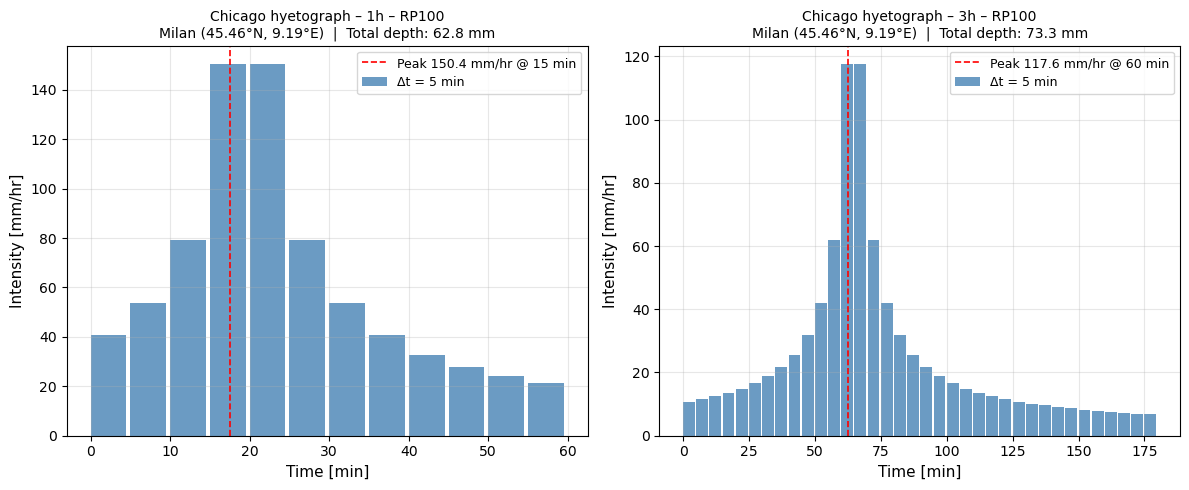

Saved → /home/admin_climatecharted_com/data/MOloch/IDF_results/chicago/chicago_hyetograph_Milan_RP100.png


In [7]:
fig, axes = plt.subplots(1, len(DURATIONS), figsize=(6 * len(DURATIONS), 5),
                          sharey=False)
if len(DURATIONS) == 1:
    axes = [axes]

for ax, dur in zip(axes, DURATIONS):
    # Extract depth at the reference point
    depth_pt = float(
        idf_data[dur].sel(lat=POINT_LAT, lon=POINT_LON, method='nearest')
    )

    df_hyet = create_chicago_hyetograph(
        total_precip_mm=depth_pt,
        duration_hours=dur,
        dt_minutes=CHICAGO_DT,
        r=CHICAGO_R,
        a=CHICAGO_A,
        b=CHICAGO_B,
        n=CHICAGO_N
    )

    ax.bar(
        df_hyet['time_min'],
        df_hyet['intensity_mm_hr'],
        width=CHICAGO_DT * 0.9,
        align='edge',
        color='steelblue',
        alpha=0.8,
        label=f'Δt = {CHICAGO_DT:.0f} min'
    )

    peak_i = df_hyet['intensity_mm_hr'].max()
    peak_t = df_hyet.loc[df_hyet['intensity_mm_hr'].idxmax(), 'time_min']
    ax.axvline(peak_t + CHICAGO_DT / 2, color='red', ls='--', lw=1.2,
               label=f'Peak {peak_i:.1f} mm/hr @ {peak_t:.0f} min')

    ax.set_xlabel('Time [min]', fontsize=11)
    ax.set_ylabel('Intensity [mm/hr]', fontsize=11)
    ax.set_title(
        f'Chicago hyetograph – {dur}h – RP{TARGET_RP}\n'
        f'{POINT_NAME} ({POINT_LAT}°N, {POINT_LON}°E)  |  '
        f'Total depth: {depth_pt:.1f} mm',
        fontsize=10
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
hyet_png = os.path.join(
    CHICAGO_DIR,
    f'chicago_hyetograph_{POINT_NAME.replace(" ","_")}_RP{TARGET_RP}.png'
)
fig.savefig(hyet_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {hyet_png}')

## 6. Spatial maps of Chicago peak intensity

In [8]:
def _make_map(ax, data, lat, lon, title, cmap, vmin, vmax, label, has_cartopy):
    """Thin wrapper to plot either with cartopy or plain imshow."""
    if has_cartopy:
        ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()],
                      crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=':')
        ax.add_feature(cfeature.LAND,      facecolor='#f5f5f0', zorder=0)
        im = ax.pcolormesh(
            lon, lat, data,
            cmap=cmap, vmin=vmin, vmax=vmax,
            transform=ccrs.PlateCarree(), zorder=1
        )
    else:
        im = ax.imshow(
            data, origin='lower',
            extent=[lon.min(), lon.max(), lat.min(), lat.max()],
            cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto'
        )
    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(label, fontsize=9)
    ax.set_title(title, fontsize=10, pad=6)
    return im


# ── gather shared coordinate arrays ──────────────────────────────────────────
lat_arr = idf_data[DURATIONS[0]]['lat'].values
lon_arr = idf_data[DURATIONS[0]]['lon'].values

print(f'Grid: {len(lat_arr)} × {len(lon_arr)}  '
      f'lat [{lat_arr.min():.2f}, {lat_arr.max():.2f}]  '
      f'lon [{lon_arr.min():.2f}, {lon_arr.max():.2f}]')

Grid: 960 × 768  lat [35.72, 49.28]  lon [4.02, 19.67]


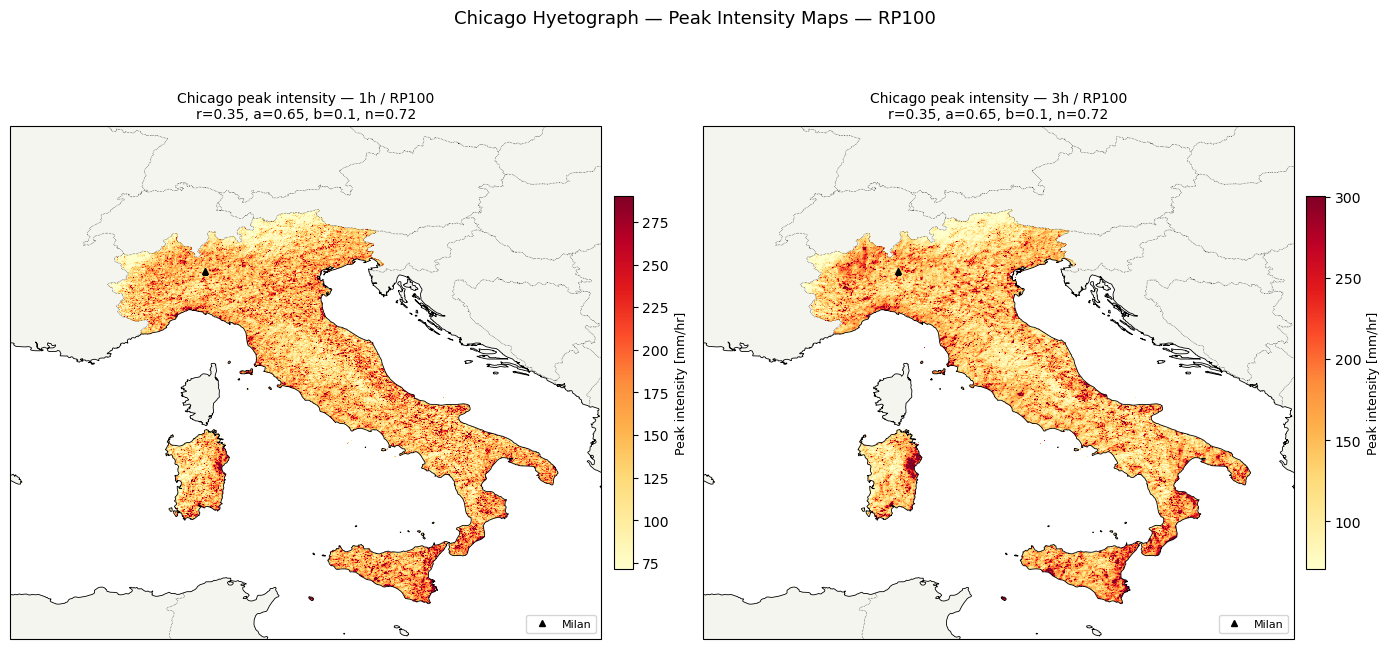

Saved → /home/admin_climatecharted_com/data/MOloch/IDF_results/chicago/chicago_peak_intensity_RP100.png


In [9]:
# ── 6.1 Peak intensity maps (one per duration) ────────────────────────────────
n_cols = len(DURATIONS)

if HAS_CARTOPY:
    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        1, n_cols, figsize=(7 * n_cols, 7),
        subplot_kw={'projection': proj}
    )
else:
    fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 6))

if n_cols == 1:
    axes = [axes]

CMAP_PEAK = 'YlOrRd'

for ax, dur in zip(axes, DURATIONS):
    peak = peak_maps[dur].copy()
    peak[peak == 0] = np.nan          # mask dry / NaN pixels

    valid  = peak[np.isfinite(peak)]
    vmin_p = np.nanpercentile(valid, 2)
    vmax_p = np.nanpercentile(valid, 98)

    _make_map(
        ax, peak, lat_arr, lon_arr,
        title=(
            f'Chicago peak intensity — {dur}h / RP{TARGET_RP}\n'
            f'r={CHICAGO_R}, a={CHICAGO_A}, b={CHICAGO_B}, n={CHICAGO_N}'
        ),
        cmap=CMAP_PEAK,
        vmin=vmin_p, vmax=vmax_p,
        label='Peak intensity [mm/hr]',
        has_cartopy=HAS_CARTOPY
    )

    # mark reference point
    if HAS_CARTOPY:
        ax.plot(POINT_LON, POINT_LAT, 'k^', ms=5,
                transform=ccrs.PlateCarree(), zorder=5, label=POINT_NAME)
    else:
        ax.plot(POINT_LON, POINT_LAT, 'k^', ms=5, label=POINT_NAME)
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle(
    f'Chicago Hyetograph — Peak Intensity Maps — RP{TARGET_RP}',
    fontsize=13, y=1.01
)
plt.tight_layout()
out_png = os.path.join(CHICAGO_DIR, f'chicago_peak_intensity_RP{TARGET_RP}.png')
fig.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_png}')

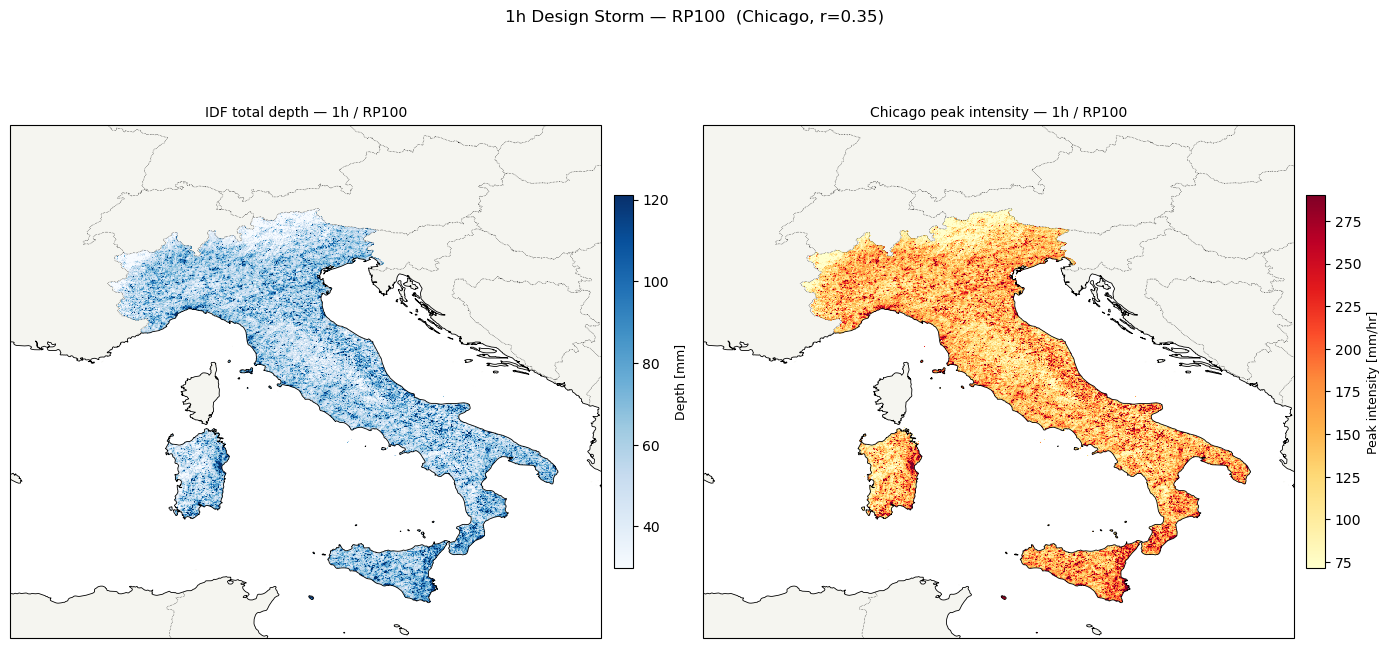

Saved → /home/admin_climatecharted_com/data/MOloch/IDF_results/chicago/chicago_depth_vs_peak_1h_RP100.png


In [10]:
# ── 6.2 Side-by-side: IDF depth vs Chicago peak intensity (1h) ───────────────
dur_check = 1   # change to 3 for the 3h event

if HAS_CARTOPY:
    proj = ccrs.PlateCarree()
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(14, 7),
        subplot_kw={'projection': proj}
    )
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

depth_2d = idf_data[dur_check].values.copy()
depth_2d[depth_2d == 0] = np.nan

_make_map(
    ax1, depth_2d, lat_arr, lon_arr,
    title=f'IDF total depth — {dur_check}h / RP{TARGET_RP}',
    cmap='Blues', vmin=np.nanpercentile(depth_2d, 2),
    vmax=np.nanpercentile(depth_2d, 98),
    label='Depth [mm]', has_cartopy=HAS_CARTOPY
)

peak_check = peak_maps[dur_check].copy()
peak_check[peak_check == 0] = np.nan
_make_map(
    ax2, peak_check, lat_arr, lon_arr,
    title=f'Chicago peak intensity — {dur_check}h / RP{TARGET_RP}',
    cmap='YlOrRd', vmin=np.nanpercentile(peak_check[np.isfinite(peak_check)], 2),
    vmax=np.nanpercentile(peak_check[np.isfinite(peak_check)], 98),
    label='Peak intensity [mm/hr]', has_cartopy=HAS_CARTOPY
)

plt.suptitle(f'{dur_check}h Design Storm — RP{TARGET_RP}  (Chicago, r={CHICAGO_R})',
             fontsize=12, y=1.01)
plt.tight_layout()
side_png = os.path.join(CHICAGO_DIR,
                         f'chicago_depth_vs_peak_{dur_check}h_RP{TARGET_RP}.png')
fig.savefig(side_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {side_png}')

## 7. Export to NetCDF
Saves one NetCDF per duration containing:
- `peak_intensity`  (lat, lon) [mm/hr] — maximum instantaneous intensity
- `total_depth`     (lat, lon) [mm]    — reproduced total depth (sanity check)
- `hyetograph`      (time, lat, lon)   [mm/hr] — full time series (**only if** `SAVE_CUBE = True`)

In [14]:
# Set True to also export the full 4-D hyetograph cube (large!)
SAVE_CUBE = False

for dur in DURATIONS:
    peak   = peak_maps[dur]
    depth  = idf_data[dur].values
    t_min  = time_axes[dur]

    ds_out = xr.Dataset(
        {
            'peak_intensity': xr.DataArray(
                peak, dims=['lat', 'lon'],
                coords={'lat': lat_arr, 'lon': lon_arr},
                attrs={
                    'units': 'mm/hr',
                    'long_name': f'Chicago peak intensity {dur}h RP{TARGET_RP}',
                    'chicago_r': CHICAGO_R, 'idf_a': CHICAGO_A,
                    'idf_b': CHICAGO_B, 'idf_n': CHICAGO_N,
                    'dt_min': CHICAGO_DT,
                }
            ),
            'total_depth': xr.DataArray(
                depth, dims=['lat', 'lon'],
                coords={'lat': lat_arr, 'lon': lon_arr},
                attrs={'units': 'mm',
                       'long_name': f'GEV return depth {dur}h RP{TARGET_RP}'}
            ),
        },
        attrs={
            'description': 'Chicago (Keifer & Chu) hyetograph applied to MORE IDF rasters',
            'return_period_years': TARGET_RP,
            'duration_hours': dur,
        }
    )

    if SAVE_CUBE:
        ds_out['hyetograph'] = xr.DataArray(
            hyeto_cubes[dur],
            dims=['time_min', 'lat', 'lon'],
            coords={'time_min': t_min, 'lat': lat_arr, 'lon': lon_arr},
            attrs={'units': 'mm/hr', 'long_name': 'Chicago intensity time series'}
        )

    nc_path = os.path.join(CHICAGO_DIR,
                            f'chicago_{dur}h_RP{TARGET_RP}.nc')
    ds_out.to_netcdf(nc_path, encoding={
        'peak_intensity': {'dtype': 'float32', 'zlib': True, 'complevel': 4},
        'total_depth':    {'dtype': 'float32', 'zlib': True, 'complevel': 4},
    })
    print(f'Saved → {nc_path}')

Saved → /home/admin_climatecharted_com/data/MOloch/IDF_results/chicago/chicago_1h_RP100.nc
Saved → /home/admin_climatecharted_com/data/MOloch/IDF_results/chicago/chicago_3h_RP100.nc


## 8. Summary statistics

In [15]:
print(f'Chicago hyetograph summary — RP{TARGET_RP}')
print(f'Parameters: r={CHICAGO_R}, a={CHICAGO_A}, b={CHICAGO_B}, n={CHICAGO_N}, Δt={CHICAGO_DT} min')
print()
header = f'{"Duration":>10s}{"Depth min":>12s}{"Depth max":>12s}{"Peak i min":>12s}{"Peak i max":>12s}{"Peak i mean":>13s}'
print(header)
print('─' * len(header))

for dur in DURATIONS:
    depth = idf_data[dur].values
    peak  = peak_maps[dur]
    mask  = np.isfinite(peak) & (peak > 0)
    print(
        f'{str(dur)+"h":>10s}'
        f'{np.nanmin(depth):12.1f}'
        f'{np.nanmax(depth):12.1f}'
        f'{peak[mask].min():12.1f}'
        f'{peak[mask].max():12.1f}'
        f'{peak[mask].mean():13.1f}'
    )

Chicago hyetograph summary — RP100
Parameters: r=0.35, a=0.65, b=0.1, n=0.72, Δt=5.0 min

  Duration   Depth min   Depth max  Peak i min  Peak i max  Peak i mean
───────────────────────────────────────────────────────────────────────
        1h        14.2 208786576.0        34.1 500202272.0       4540.1
        3h        24.6235345920655360.0        39.5377212180103168.0 4221534208.0


---
## Notes

### Chicago (Keifer & Chu) formula
The instantaneous intensity on each limb of the hyetograph is:

**Before peak** (`t ≤ r·D`):  
$$i(t) = a \cdot \frac{(1-n)\, t_a + b}{(t_a + b)^{n+1}}, \quad t_a = t / r$$

**After peak** (`t > r·D`):  
$$i(t) = a \cdot \frac{(1-n)\, t_a + b}{(t_a + b)^{n+1}}, \quad t_a = (D - t) / (1 - r)$$

where `D` is the total duration [hr], `r` the peak-position ratio, and `a, b, n`
are the IDF parameters.

### Pixel-wise IDF parameters
For maximum accuracy, derive `a` and `n` by fitting the power-law IDF to the GEV
return values across the five durations (1h, 3h, 6h, 12h, 24h) at each pixel.  
A simple log-linear regression of `log(i) = log(a) − n·log(t + b)` suffices.  
Save the fitted maps and uncomment Section 3b.

### Choosing `r`
Italian meteorological practice typically uses `r = 0.35` (peak at 35% of event
duration), consistent with convective storm structures observed in the Po Valley
and the Apennines.  Coastal Mediterranean zones sometimes use `r = 0.40`.

### Output files
| File | Contents |
|------|----------|
| `chicago_1h_RP{n}.nc` | peak_intensity, total_depth rasters |
| `chicago_3h_RP{n}.nc` | peak_intensity, total_depth rasters |
| `chicago_peak_intensity_RP{n}.png` | side-by-side spatial maps |
| `chicago_hyetograph_<city>_RP{n}.png` | single-point time series |
